<a href="https://colab.research.google.com/github/hridya-r-n/MCA-lab/blob/main/Tutorial/DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Learned Weights: [0.1 0.1]
 Learned Bias:    -0.1
 Predictions:     [0 1 1 1]


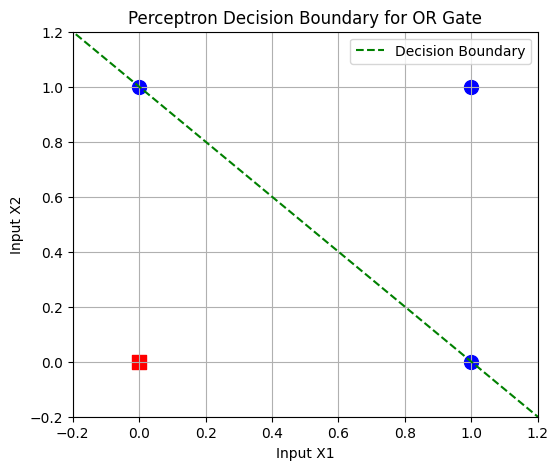

In [11]:
import numpy as np
import matplotlib.pyplot as plt

#  Define the Perceptron Class
class Perceptron:
    def __init__(self, learning_rate=0.1, epochs=100):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def step_function(self, x):
        return np.where(x >= 0, 1, 0)

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # Initialize weights and bias to zeros
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Training loop
        for epoch in range(self.epochs):
            for i in range(n_samples):
                # Linear combination: z = w1*x1 + w2*x2 + b
                linear_output = np.dot(X[i], self.weights) + self.bias

                # Activation function
                y_predicted = self.step_function(linear_output)

                # Update rule: w = w + lr * (y_true - y_pred) * x
                update = self.lr * (y[i] - y_predicted)
                self.weights += update * X[i]
                self.bias += update

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.step_function(linear_output)

# Define Dataset (OR Gate)
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])
y = np.array([0, 1, 1, 1])  # target

# Train the Model
p = Perceptron(learning_rate=0.1, epochs=10)
p.fit(X, y)

predictions = p.predict(X)
print(" Learned Weights:", p.weights)
print(" Learned Bias:   ", p.bias)
print(" Predictions:    ", predictions)

# Plot the Decision Boundary
plt.figure(figsize=(6, 5))
for i in range(len(y)):
    color = 'blue' if y[i] == 1 else 'red'
    marker = 'o' if y[i] == 1 else 's'
    plt.scatter(X[i, 0], X[i, 1], color=color, marker=marker, s=100)

# Decision boundary eqn: w1*x1 + w2*x2 + b = 0 => x2 = -(w1*x1 + b) / w2
x1 = np.linspace(-0.5, 1.5, 100)
x2 = -(p.weights[0] * x1 + p.bias) / p.weights[1]

plt.plot(x1, x2, color='green', linestyle='--', label='Decision Boundary')
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.title("Perceptron Decision Boundary for OR Gate")
plt.xlabel("Input X1")
plt.ylabel("Input X2")
plt.legend()
plt.grid(True)
plt.show()

In [2]:
import numpy as np

class Perceptron:
    def __init__(self, learning_rate=0.1, epochs=20):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])

        for _ in range(self.epochs):
            for i in range(len(X)):
                z = np.dot(X[i], self.weights) + self.bias

                if z >= 0:
                    prediction = 1
                else:
                    prediction = 0

                error = y[i] - prediction

                self.weights += self.learning_rate * error * X[i]
                self.bias += self.learning_rate * error

    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        return (z >= 0).astype(int)


# OR gate
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 1])

# Create and train perceptron
p = Perceptron(learning_rate=0.1, epochs=20)
p.fit(X, y)

print("Weights:", p.weights)
print("Bias:", p.bias)
print("Predictions:", p.predict(X))

Weights: [0.1 0.1]
Bias: -0.1
Predictions: [0 1 1 1]
